# Image Classification

In [13]:
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import InterpolationMode

## Configuration

In [14]:
# Simple variables
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 20
EARLY_STOP_PATIENCE = 4
LR = 3e-6
WEIGHT_DECAY = 1e-6
IMAGE_SIZE = 224
DETECTION_THRESHOLD = 0.50
TRAIN_RATIO = 0.60
VAL_RATIO = 0.25
TEST_RATIO = 0.15
MODEL_PATH = Path('output/food-detector-model.pth')

# Setup
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Data Loading

In [15]:
def get_data_loaders(dataset_dir):
    dataset_dir = Path(dataset_dir)
    all_dataset = datasets.ImageFolder(dataset_dir)
    class_names = all_dataset.classes
    
    indices = np.arange(len(all_dataset))
    targets = np.array(all_dataset.targets)
    
    # 70% train
    train_idx, temp_idx = train_test_split(
        indices, test_size=1-TRAIN_RATIO, stratify=targets, random_state=SEED
    )
    
    # 10% val, 10% test
    temp_targets = targets[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, stratify=temp_targets, random_state=SEED
    )
    
    # train_tfms = transforms.Compose([
    #     transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    #     transforms.RandomHorizontalFlip(p=0.5),
    #     transforms.RandomRotation(15),
    #     transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    #     transforms.ToTensor(),
    #     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # ])
    step_angles = list(range(0, 360, 30))
    train_tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        # transforms.RandomRotation(8),
        transforms.Lambda(lambda img: transforms.functional.rotate(
            img,
            angle=random.choice(step_angles),
            interpolation=InterpolationMode.BILINEAR,
            fill=0
        )),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    eval_tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_ds = datasets.ImageFolder(dataset_dir, transform=train_tfms)
    train_ds = Subset(train_ds, train_idx)
    
    val_ds = datasets.ImageFolder(dataset_dir, transform=eval_tfms)
    val_ds = Subset(val_ds, val_idx)
    
    test_ds = datasets.ImageFolder(dataset_dir, transform=eval_tfms)
    test_ds = Subset(test_ds, test_idx)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    return train_loader, val_loader, test_loader, class_names


dataset_dir = Path('dataset')
train_loader, val_loader, test_loader, class_names = get_data_loaders(dataset_dir)

print(f'Classes: {class_names}')
print(f'Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}')

Classes: ['background', 'food', 'water']
Train: 1213, Val: 405, Test: 405


## Model

In [16]:
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.25),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model


model = build_model(len(class_names)).to(device)
print(f'Model: ResNet18, Classes: {len(class_names)}')

Model: ResNet18, Classes: 3


## Training

In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)

In [18]:
# Calculate class weights
train_targets = torch.tensor(train_loader.dataset.dataset.targets)[train_loader.dataset.indices]
class_counts = torch.bincount(train_targets, minlength=len(class_names)).float()
class_weights = class_counts.sum() / (class_counts + 1e-9)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

history = []
best_acc = -1
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_acc)
    
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })
    
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({'model_state_dict': model.state_dict()}, MODEL_PATH)
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print('Early stopping')
        break

print(f'\nBest val acc: {best_acc:.4f}')
print(f'Saved: {MODEL_PATH}')

/home/sk/miniconda3/envs/ds/lib/python3.14/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01 | train_loss 1.0665 train_acc 0.5359 | val_loss 0.9580 val_acc 0.6815
Epoch 02 | train_loss 0.8346 train_acc 0.7082 | val_loss 0.7759 val_acc 0.8272
Epoch 03 | train_loss 0.6790 train_acc 0.8467 | val_loss 0.6367 val_acc 0.9210
Epoch 04 | train_loss 0.5728 train_acc 0.8994 | val_loss 0.5471 val_acc 0.9531
Epoch 05 | train_loss 0.5131 train_acc 0.9233 | val_loss 0.4762 val_acc 0.9679
Epoch 06 | train_loss 0.4611 train_acc 0.9291 | val_loss 0.4242 val_acc 0.9753
Epoch 07 | train_loss 0.4165 train_acc 0.9497 | val_loss 0.3860 val_acc 0.9827
Epoch 08 | train_loss 0.3941 train_acc 0.9580 | val_loss 0.3645 val_acc 0.9877
Epoch 09 | train_loss 0.3748 train_acc 0.9596 | val_loss 0.3363 val_acc 0.9852
Epoch 10 | train_loss 0.3533 train_acc 0.9571 | val_loss 0.3189 val_acc 0.9901
Epoch 11 | train_loss 0.3549 train_acc 0.9563 | val_loss 0.3068 val_acc 0.9852
Epoch 12 | train_loss 0.3295 train_acc 0.9687 | val_loss 0.2961 val_acc 0.9852
Epoch 13 | train_loss 0.3167 train_acc 0.9711 | val_

## Evaluation

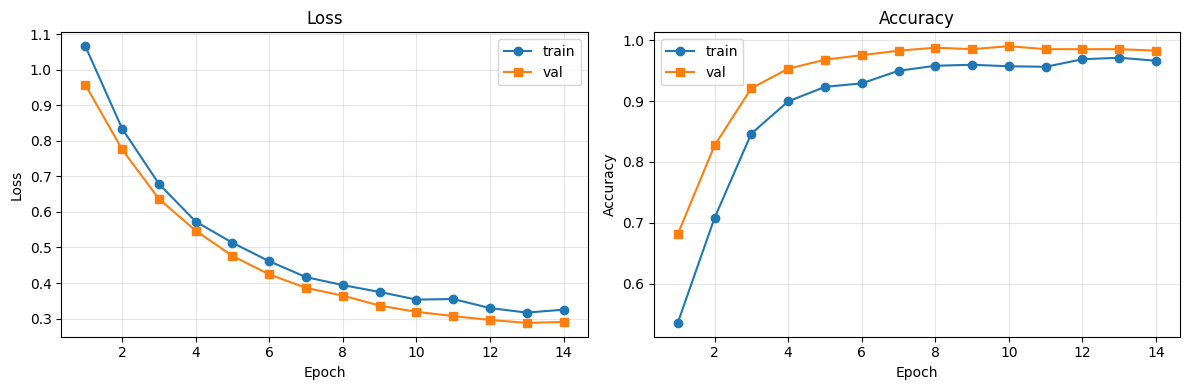

In [19]:
# Plot history
epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]
train_acc = [h['train_acc'] for h in history]
val_acc = [h['val_acc'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, label='train', marker='o')
axes[0].plot(epochs, val_loss, label='val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_acc, label='train', marker='o')
axes[1].plot(epochs, val_acc, label='val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Test evaluation
test_loss, test_acc, y_true, y_pred = eval_epoch(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.2795
Test Accuracy: 0.9877


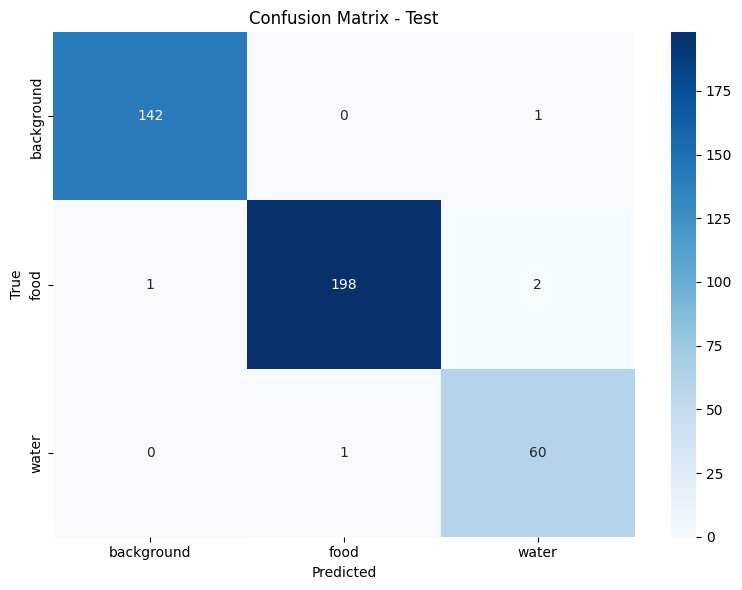

In [21]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test')
plt.tight_layout()
plt.show()

In [22]:
# Classification report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

  background     0.9930    0.9930    0.9930       143
        food     0.9950    0.9851    0.9900       201
       water     0.9524    0.9836    0.9677        61

    accuracy                         0.9877       405
   macro avg     0.9801    0.9872    0.9836       405
weighted avg     0.9879    0.9877    0.9877       405



## Prediction

In [23]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    
    tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    x = tfms(image).unsqueeze(0).to(device)
    model.eval()
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    probs_dict = {class_names[i]: float(probs[i] * 100.0) for i in range(len(class_names))}
    pred_class = class_names[probs.argmax()]
    
    return pred_class, probs_dict


In [24]:
path = "Image.png"
pred_class, probs = predict_image(path)
print({
    'image': str(path),
    'predicted_class': pred_class,
    'confidence': float(probs[pred_class]),
    'probabilities': {k: round(v, 2) for k, v in probs.items()},
})

{'image': 'Image.png', 'predicted_class': 'water', 'confidence': 98.47293853759766, 'probabilities': {'background': 0.96, 'food': 0.57, 'water': 98.47}}
